# Current-Collapse Index for Mismatch-Induced Instantaneous Efficiency Degradation

**Single, self-contained analysis notebook.** Reproduces every quantitative
result and figure for the manuscript directly from the raw `.mat` I–V traces.

Pipeline: load panel-resolved `.mat` files → extract I–V features (*V*<sub>oc</sub>, *I*<sub>sc</sub>, *P*<sub>mpp</sub>, FF) → irradiance-normalized
relative efficiency η<sub>rel</sub> → current-collapse ratio *R*<sub>I</sub> →
correlation / linear-fit statistics (Table II) → Figs. 1–6.

Outputs are written next to the dataset: a per-trace table (`.csv`/`.parquet`),
a condition summary, the correlation statistics (`.csv`/`.json`/`.txt`), and all
figures as 300-dpi PNG plus vector PDF.

_Note on statistics: every number is computed from the data at run time; nothing
is hard-coded. The dataset is small (a handful of traces per condition), so the
reported p-values are interpreted accordingly and Spearman ρ is reported
alongside Pearson r._

**Revision note:** This corrected version fixes irradiance-field detection (`IRR`) and therefore restores Figs. 1, 3, and 6.

## 0. Setup and configuration

`BASE_DIR` is a best guess. If it is wrong, Section 1 automatically searches your Drive for a `ProcessedData` folder that contains `.mat` files — so in most cases you can just run all cells. If auto-search fails, set `BASE_DIR` to the folder that holds `M5_30112/` and `SP090P/`.

In [1]:
# Mount Google Drive when running in Colab (no-op elsewhere)
import sys, os
if "google.colab" in sys.modules:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")


Mounted at /content/drive


In [21]:
import os, re, json
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy import stats

# ---- User configuration -------------------------------------------------
BASE_DIR = ("/content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/Experimental data for Mismatching Faults of Photovoltaic Modules/ProcessedData")

# If BASE_DIR is not found, Section 1 auto-searches these roots for the dataset.
SEARCH_ROOTS = ["/content/drive/MyDrive", "/content/drive/Shareddrives",
                "/content/drive", "/content"]

OUT_DIR  = "/content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs"
FIG_DIR  = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ---- Analysis constants -------------------------------------------------
REF_PERCENTILE         = 95     # robust reference = 95th pct of clean/unshaded Phi
CLIP_ETA_REL           = True   # clip eta_rel to <= 1 for plots/tables
ISC_COLLAPSE_THRESHOLD = 0.5    # R_I threshold separating collapse from attenuation
SAVE_DPI               = 300

# Condition label order used throughout
COND_ORDER = ["Clean", "Soiled", "Shaded", "Other"]

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.3})
print("Config OK. Output ->", OUT_DIR)


Config OK. Output -> /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs


## 1. Load `.mat` files and extract I–V features

The loader walks each panel's `ElectricalData` folder, reads every `.mat`,
and infers the surface/shading condition from the file name (`PanelA_Clean`, `PanelB_Shadow`, `Panel1_Dirt`, …).

In [22]:
def _squeeze(x: Any) -> Any:
    if isinstance(x, np.ndarray):
        x = np.squeeze(x)
        if x.shape == ():
            return x.item()
    return x

def _is_vector(a: Any) -> bool:
    if not isinstance(a, np.ndarray):
        return False
    a = np.squeeze(a)
    return a.ndim == 1 and a.size >= 5

def _safe_float(x: Any) -> Optional[float]:
    try:
        x = _squeeze(x)
        if isinstance(x, (float, int, np.floating, np.integer)):
            return float(x)
    except Exception:
        return None
    return None

def _find_key(d: Dict[str, Any], patterns: List[str]) -> Optional[str]:
    for pat in patterns:
        rx = re.compile(pat, re.IGNORECASE)
        for k in d:
            if rx.search(k):
                return k
    return None

def infer_condition(filename: str) -> str:
    """Map a file name to one of: Clean / Soiled / Shaded / Other."""
    n = os.path.basename(filename).lower()
    if any(t in n for t in ("shadow", "shade", "shad")):
        return "Shaded"
    if "dirt" in n:
        return "Soiled"
    if "clean" in n:
        return "Clean"
    return "Other"

def list_mat(folder: str) -> List[str]:
    out = []
    if os.path.isdir(folder):
        for root, _, files in os.walk(folder):
            out += [os.path.join(root, f) for f in files if f.lower().endswith(".mat")]
    return sorted(out)


In [23]:
def load_iv(mat_path: str) -> Tuple[np.ndarray, np.ndarray, Optional[float], Optional[float], Dict[str, Any]]:
    """
    Return (V, I, irradiance, temperature_C, scalar_fields) from one .mat file.

    This version fixes the original IRR bug:
    - old pattern r"\\birr\\b" searched for a literal backslash-b, so the key "IRR" was missed.
    - new pattern r"\birr\b" correctly matches "IRR".

    It also reads the scalar fields already present in the dataset, when available:
    IRR, T, Isc, Voc, Pmpp, Vmpp, Impp.
    """
    raw = loadmat(mat_path, squeeze_me=False, struct_as_record=False)
    d = {k: _squeeze(v) for k, v in raw.items() if not k.startswith("__")}

    # Exact known field names first, then robust fallbacks.
    v_key = "Vpanel" if "Vpanel" in d else _find_key(d, [r"^vpanel$", r"^v(panel)?$", r"volt", r"^v$"])
    i_key = "Ipanel" if "Ipanel" in d else _find_key(d, [r"^ipanel$", r"^i(panel)?$", r"curr", r"^i$"])

    v = i = None
    if v_key and i_key and _is_vector(d.get(v_key)) and _is_vector(d.get(i_key)):
        v = np.asarray(np.squeeze(d[v_key]), dtype=float)
        i = np.asarray(np.squeeze(d[i_key]), dtype=float)
    else:
        # Fall back to the two longest numeric vectors.
        vecs = [(k, np.squeeze(val)) for k, val in d.items()
                if isinstance(val, np.ndarray) and _is_vector(val)]
        vecs.sort(key=lambda kv: kv[1].size, reverse=True)
        if len(vecs) >= 2:
            a1 = np.asarray(vecs[0][1], dtype=float)
            a2 = np.asarray(vecs[1][1], dtype=float)
            # In this dataset voltage has the larger numeric range.
            v, i = (a1, a2) if np.nanmax(np.abs(a1)) >= np.nanmax(np.abs(a2)) else (a2, a1)

    if v is None or i is None:
        raise ValueError(f"Could not extract I-V vectors from: {mat_path}")

    n = min(v.size, i.size)
    v, i = v[:n], i[:n]

    # Drop non-finite pairs.
    ok = np.isfinite(v) & np.isfinite(i)
    v, i = v[ok], i[ok]
    if len(v) < 5:
        raise ValueError(f"Too few finite I-V points in: {mat_path}")

    # Sort by ascending voltage for interpolation/plotting.
    order = np.argsort(v)
    v, i = v[order], i[order]

    # Correct, robust scalar key detection.
    irr_key = "IRR" if "IRR" in d else _find_key(d, [r"\birr\b", r"irradi", r"w/m", r"poa"])
    t_key   = "T"   if "T"   in d else _find_key(d, [r"\btemp\b", r"tpanel", r"t_mod", r"tmod", r"^t$"])

    irr = _safe_float(d.get(irr_key)) if irr_key else None
    t_c = _safe_float(d.get(t_key)) if t_key else None

    scalar_fields = {}
    for key in ["IRR", "T", "Isc", "Voc", "Pmpp", "Vmpp", "Impp"]:
        if key in d:
            val = _safe_float(d[key])
            if val is not None:
                scalar_fields[key] = val

    return v, i, irr, t_c, scalar_fields


def _interp_at_x(x: np.ndarray, y: np.ndarray, x0: float) -> float:
    """Linear interpolation y(x0), with endpoint fallback when x0 is outside the measured range."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 2:
        return float("nan")
    order = np.argsort(x)
    x, y = x[order], y[order]
    if x0 < x[0] or x0 > x[-1]:
        return float(y[np.argmin(np.abs(x - x0))])
    return float(np.interp(x0, x, y))


def iv_metrics(v: np.ndarray, i: np.ndarray, scalar_fields: Optional[Dict[str, Any]] = None) -> Dict[str, float]:
    """
    Extract I-V metrics.

    Preference order:
    1) Use trusted scalar fields stored in the .mat file when available.
    2) Otherwise reconstruct from vectors.

    A separate validation table is produced later, so the paper can state that
    reconstructed and file-provided metrics were cross-checked.
    """
    scalar_fields = scalar_fields or {}

    p = v * i
    k = int(np.nanargmax(p))
    pmpp_rec, vmpp_rec, impp_rec = float(p[k]), float(v[k]), float(i[k])

    # I_sc by interpolation/extrapolation to V=0.
    isc_rec = _interp_at_x(v, i, 0.0)

    # V_oc by interpolation of V(I=0). If current never reaches zero, use stored Voc if available;
    # otherwise use the highest measured voltage as a conservative endpoint estimate.
    if np.nanmin(i) <= 0 <= np.nanmax(i):
        voc_rec = _interp_at_x(i, v, 0.0)
    else:
        voc_rec = float(np.nanmax(v))

    voc  = float(scalar_fields.get("Voc",  voc_rec))
    isc  = float(scalar_fields.get("Isc",  isc_rec))
    pmpp = float(scalar_fields.get("Pmpp", pmpp_rec))
    vmpp = float(scalar_fields.get("Vmpp", vmpp_rec))
    impp = float(scalar_fields.get("Impp", impp_rec))

    # Ensure sign convention is usable if a dataset stores current negative.
    if isc < 0 and pmpp < 0:
        isc, impp, pmpp = abs(isc), abs(impp), abs(pmpp)
    elif isc < 0:
        isc = abs(isc)

    ff = float(pmpp / (voc * isc)) if np.isfinite(voc) and np.isfinite(isc) and voc > 0 and isc > 0 else float("nan")

    return {
        "Voc_V": voc, "Isc_A": isc, "Pmpp_W": pmpp, "Vmpp_V": vmpp, "Impp_A": impp, "FF": ff,
        "Voc_rec_V": voc_rec, "Isc_rec_A": isc_rec, "Pmpp_rec_W": pmpp_rec,
        "Vmpp_rec_V": vmpp_rec, "Impp_rec_A": impp_rec
    }

In [24]:
# ---- Locate the dataset: honor BASE_DIR, otherwise auto-search ----------
def _has_mat_below(path: str) -> bool:
    if not os.path.isdir(path):
        return False
    for _, _, files in os.walk(path):
        if any(f.lower().endswith(".mat") for f in files):
            return True
    return False

def find_processed_root(base_dir: str, search_roots: List[str], max_dirs: int = 30000) -> Optional[str]:
    if _has_mat_below(base_dir):
        return base_dir
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        seen = 0
        for dirpath, _, _ in os.walk(root):
            seen += 1
            if seen > max_dirs:
                break
            if os.path.basename(dirpath).lower() == "processeddata" and _has_mat_below(dirpath):
                return dirpath
    return None

def discover_panels(processed_root: str) -> Dict[str, str]:
    """Each immediate subfolder is a panel; prefer its ElectricalData child."""
    panels = {}
    for name in sorted(os.listdir(processed_root)):
        pdir = os.path.join(processed_root, name)
        if not os.path.isdir(pdir):
            continue
        elec = os.path.join(pdir, "ElectricalData")
        target = elec if os.path.isdir(elec) else pdir
        if _has_mat_below(target):
            panels[name] = target
    return panels

PROCESSED_ROOT = find_processed_root(BASE_DIR, SEARCH_ROOTS)
if PROCESSED_ROOT is None:
    print("[ERROR] Could not locate the dataset.")
    print("  Drive mounted:", os.path.isdir("/content/drive"))
    if os.path.isdir("/content/drive/MyDrive"):
        print("  Top of MyDrive:", sorted(os.listdir("/content/drive/MyDrive"))[:25])
    raise FileNotFoundError(
        "Set BASE_DIR (cell above) to the folder containing M5_30112/ and SP090P/ "
        "(your 'ProcessedData' folder), then re-run. If the data is under "
        "'Shared with me', add a shortcut to it in My Drive first so Colab can see it.")

PANELS = discover_panels(PROCESSED_ROOT)
print("Dataset root :", PROCESSED_ROOT)
for _k, _v in PANELS.items():
    print(f"  panel {_k}: {_v}")
if not PANELS:
    raise FileNotFoundError(f"No panel subfolders with .mat files under {PROCESSED_ROOT}")

# ---- Extract per-trace features -----------------------------------------
rows = []
for panel, folder in PANELS.items():
    files = list_mat(folder)
    if not files:
        print(f"[WARN] no .mat files for {panel} at {folder}")
        continue
    for fp in files:
        try:
            v, i, irr, t_c, scalar_fields = load_iv(fp)
        except Exception as e:
            print(f"[WARN] skip {fp}: {e}")
            continue
        m = iv_metrics(v, i, scalar_fields)
        phi = (m["Pmpp_W"] / irr) if (irr is not None and np.isfinite(irr) and irr > 0) else np.nan
        rows.append({"panel": panel, "file": fp, "trace": os.path.basename(fp),
                     "condition": infer_condition(fp), "G_Wm2": irr, "T_C": t_c,
                     **m, "Phi": phi})

if not rows:
    raise RuntimeError("No I-V traces could be parsed — check the .mat paths/contents above.")

df = pd.DataFrame(rows)

print(f"\nLoaded {len(df)} traces across {df['panel'].nunique()} panels.")
print("Condition counts:")
print(df.groupby(["panel", "condition"]).size())

missing_g = int(df["G_Wm2"].isna().sum())
if missing_g:
    print(f"\n[WARN] {missing_g} traces have missing irradiance. eta_rel will be NaN for those traces.")
else:
    print("\nIrradiance field OK: no missing G_Wm2 values.")

display_cols = ["panel", "trace", "condition", "G_Wm2", "T_C", "Voc_V", "Isc_A", "Pmpp_W", "FF"]
df[display_cols].head(30)

Dataset root : /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/Experimental data for Mismatching Faults of Photovoltaic Modules/ProcessedData
  panel M5_30112: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/Experimental data for Mismatching Faults of Photovoltaic Modules/ProcessedData/M5_30112/ElectricalData
  panel SP090P: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/Experimental data for Mismatching Faults of Photovoltaic Modules/ProcessedData/SP090P/ElectricalData

Loaded 17 traces across 2 panels.
Condition counts:
panel     condition
M5_30112  Clean        3
          Shaded       3
          Soiled       3
SP090P    Clean        3
          Shaded       2
          Soiled       3
dtype: int64

Irradiance field OK: no missing G_Wm2 values.


,panel,trace,condition,G_Wm2,T_C,Voc_V,Isc_A,Pmpp_W,FF
0,M5_30112,PanelA_Clean.mat,Clean,910.0,42.6,20.12,1.76255,24.11,0.679873
1,M5_30112,PanelA_Dirt.mat,Soiled,900.0,39.4,19.74,1.74188,23.32,0.678208
2,M5_30112,PanelA_Shadow.mat,Shaded,934.0,42.7,19.60,0.43500,6.98,0.818672
3,M5_30112,PanelB_Clean.mat,Clean,948.0,40.1,21.06,1.81649,23.33,0.609850
4,M5_30112,PanelB_Dirt.mat,Soiled,950.0,40.3,21.22,1.77813,23.03,0.610359
5,M5_30112,PanelB_Shadow.mat,Shaded,970.0,39.9,20.50,0.44000,6.43,0.712860
6,M5_30112,PanelC_Clean.mat,Clean,900.0,34.2,21.19,1.70726,22.21,0.613929
7,M5_30112,PanelC_Dirt.mat,Soiled,990.0,37.4,21.30,1.70000,22.05,0.608948
8,M5_30112,PanelC_Shadow.mat,Shaded,900.0,37.9,21.00,0.34300,5.76,0.799667
9,SP090P,Panel1_Clean.mat,Clean,920.0,40.3,19.70,5.02698,54.11,0.546392


## 2. Relative efficiency η<sub>rel</sub> and current-collapse ratio *R*<sub>I</sub>

Per panel: reference Φ<sub>ref</sub> = 95th percentile of Φ over clean traces; η<sub>rel,raw</sub> = Φ/Φ<sub>ref</sub> (clipped copy η<sub>rel</sub>); *R*<sub>I</sub> = *I*<sub>sc</sub> / median(*I*<sub>sc</sub> over clean).

In [25]:
df["eta_rel_raw"] = np.nan
df["eta_rel"]     = np.nan
df["Phi_ref"]     = np.nan
df["Isc_clean_median"] = np.nan
df["R_I"]         = np.nan
df["flag_collapse"] = False

for panel in df["panel"].dropna().unique():
    sel = df["panel"] == panel
    sub = df[sel]

    clean_phi = sub.loc[sub["condition"] == "Clean", "Phi"].dropna()
    ref_pool  = clean_phi if len(clean_phi) else sub["Phi"].dropna()
    phi_ref   = float(np.nanpercentile(ref_pool.values, REF_PERCENTILE)) if len(ref_pool) else np.nan

    if np.isfinite(phi_ref) and phi_ref > 0:
        df.loc[sel, "Phi_ref"]     = phi_ref
        df.loc[sel, "eta_rel_raw"] = df.loc[sel, "Phi"] / phi_ref
        df.loc[sel, "eta_rel"]     = (np.minimum(df.loc[sel, "eta_rel_raw"], 1.0)
                                      if CLIP_ETA_REL else df.loc[sel, "eta_rel_raw"])

    clean_isc = sub.loc[sub["condition"] == "Clean", "Isc_A"].dropna()
    isc_pool  = clean_isc if len(clean_isc) else sub["Isc_A"].dropna()
    isc_med   = float(np.nanmedian(isc_pool.values)) if len(isc_pool) else np.nan
    if np.isfinite(isc_med) and isc_med > 0:
        df.loc[sel, "Isc_clean_median"] = isc_med
        df.loc[sel, "R_I"] = df.loc[sel, "Isc_A"] / isc_med
        df.loc[sel, "flag_collapse"] = df.loc[sel, "R_I"] < ISC_COLLAPSE_THRESHOLD

csv_path = os.path.join(OUT_DIR, "iv_summary.csv")
df.to_csv(csv_path, index=False)
try:
    df.to_parquet(os.path.join(OUT_DIR, "iv_summary.parquet"), index=False)
except Exception as e:
    print("[INFO] parquet skipped:", e)
print("Saved per-trace table ->", csv_path)
print("\nmax eta_rel by panel (should be ~1.0):")
print(df.groupby("panel")["eta_rel"].max())


Saved per-trace table -> /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs/iv_summary.csv

max eta_rel by panel (should be ~1.0):
panel
M5_30112    1.0
SP090P      1.0
Name: eta_rel, dtype: float64


## 3. Condition summary (feeds the manuscript Dataset table)

Per-condition trace counts, η<sub>rel</sub> statistics, and the measured ranges of *G* and *T*.

In [26]:
def fmt_range(s):
    s = s.dropna()
    return f"{s.min():.0f}–{s.max():.0f}" if len(s) else "—"

summ = (df.groupby(["panel", "condition"], observed=False)
          .agg(n=("eta_rel", "size"),
               eta_mean=("eta_rel", "mean"),
               eta_min=("eta_rel", "min"),
               eta_max=("eta_rel", "max"),
               R_I_mean=("R_I", "mean"),
               R_I_min=("R_I", "min"),
               R_I_max=("R_I", "max"),
               FF_mean=("FF", "mean"),
               Pmpp_mean_W=("Pmpp_W", "mean"))
          .reset_index())

ranges = []
for (panel, condition), g in df.groupby(["panel", "condition"], observed=False):
    ranges.append({"panel": panel, "condition": condition,
                   "G_range": fmt_range(g["G_Wm2"]),
                   "T_range_C": fmt_range(g["T_C"])})
ranges = pd.DataFrame(ranges)

summary = summ.merge(ranges, on=["panel", "condition"])
summary["condition"] = pd.Categorical(summary["condition"], COND_ORDER, ordered=True)
summary = summary.sort_values(["panel", "condition"]).reset_index(drop=True)
summary.to_csv(os.path.join(OUT_DIR, "condition_summary.csv"), index=False)

# within-condition temperature spread (supports the temperature-independence claim)
tspread = df.groupby(["panel", "condition"], observed=False)["T_C"].apply(
    lambda s: (s.max() - s.min()) if s.notna().any() else np.nan)
print("Within-condition temperature spread (degC):")
print(tspread.dropna())
summary

Within-condition temperature spread (degC):
panel     condition
M5_30112  Clean        8.4
          Shaded       4.8
          Soiled       2.9
SP090P    Clean        1.0
          Shaded       0.5
          Soiled       4.2
Name: T_C, dtype: float64


,panel,condition,n,eta_mean,eta_min,eta_max,R_I_mean,R_I_min,R_I_max,FF_mean,Pmpp_mean_W,G_range,T_range_C
0,M5_30112,Clean,3,0.957712,0.935274,1.000000,0.999745,0.968631,1.030603,0.634551,23.216667,900–948,34–43
1,M5_30112,Soiled,3,0.917498,0.846459,0.984733,0.987208,0.964512,1.008839,0.632505,22.800000,900–990,37–40
2,M5_30112,Shaded,3,0.259722,0.243227,0.284015,0.230348,0.194604,0.249638,0.777066,6.390000,900–970,38–43
3,SP090P,Clean,3,0.911460,0.749546,1.000000,0.998763,0.995976,1.000312,0.643411,66.960000,920–950,39–40
4,SP090P,Soiled,3,0.708245,0.124735,1.000000,0.721015,0.151231,1.009693,0.697795,54.340000,935–970,39–43
5,SP090P,Shaded,2,0.145014,0.125001,0.165027,0.128746,0.118199,0.139292,0.807779,10.735000,940–946,41–42


## 4. Correlation and linear-fit statistics — **Table II**

Regression of η<sub>rel,raw</sub> on *R*<sub>I</sub> per panel: Pearson *r* and
two-sided *p*, Spearman ρ, *R*², and the least-squares slope/intercept.
These are the values to paste into Table II of the manuscript.

In [27]:
def corr_stats(sub: pd.DataFrame) -> Dict[str, float]:
    d = sub[["R_I", "eta_rel_raw"]].dropna()
    x, y = d["R_I"].values, d["eta_rel_raw"].values
    out = {"n": int(len(d))}
    if len(d) >= 3 and np.std(x) > 0 and np.std(y) > 0:
        r, p = stats.pearsonr(x, y)
        rho, p_s = stats.spearmanr(x, y)
        lin = stats.linregress(x, y)
        out.update({"pearson_r": float(r), "pearson_p": float(p),
                    "spearman_rho": float(rho), "spearman_p": float(p_s),
                    "R2": float(r**2), "slope": float(lin.slope),
                    "intercept": float(lin.intercept)})
    else:
        out.update({k: np.nan for k in
                    ["pearson_r", "pearson_p", "spearman_rho", "spearman_p",
                     "R2", "slope", "intercept"]})
    return out

stats_by_panel = {p: corr_stats(df[df["panel"] == p]) for p in sorted(df["panel"].unique())}
stats_all = corr_stats(df)            # pooled across panels
stats_by_panel["ALL_PANELS"] = stats_all

# Table II (manuscript columns) + extras for the record
table2 = pd.DataFrame([
    {"Module": p,
     "Pearson r": s["pearson_r"], "p-value": s["pearson_p"],
     "R2": s["R2"], "Fit slope": s["slope"],
     "Spearman rho": s["spearman_rho"], "Intercept": s["intercept"], "n": s["n"]}
    for p, s in stats_by_panel.items()
])
table2.to_csv(os.path.join(OUT_DIR, "table2_correlation.csv"), index=False)
with open(os.path.join(OUT_DIR, "table2_correlation.json"), "w") as f:
    json.dump(stats_by_panel, f, indent=2)

# human-readable dump for pasting into the paper
lines = ["Table II - R_I vs eta_rel_raw correlation / linear fit", ""]
for p, s in stats_by_panel.items():
    if np.isnan(s["pearson_r"]):
        lines.append(f"{p}: n={s['n']} (insufficient data)")
    else:
        lines.append(
            f"{p}: n={s['n']}  Pearson r={s['pearson_r']:.3f} (p={s['pearson_p']:.2e})  "
            f"Spearman rho={s['spearman_rho']:.3f}  R2={s['R2']:.3f}  "
            f"slope={s['slope']:.3f}  intercept={s['intercept']:.3f}")
with open(os.path.join(OUT_DIR, "table2_correlation.txt"), "w") as f:
    f.write("\n".join(lines) + "\n")
print("\n".join(lines))
table2.round(4)


Table II - R_I vs eta_rel_raw correlation / linear fit

M5_30112: n=9  Pearson r=0.992 (p=1.37e-07)  Spearman rho=0.733  R2=0.984  slope=0.889  intercept=0.055
SP090P: n=8  Pearson r=0.978 (p=2.50e-05)  Spearman rho=0.857  R2=0.957  slope=0.948  intercept=0.009
ALL_PANELS: n=17  Pearson r=0.984 (p=1.36e-12)  Spearman rho=0.779  R2=0.968  slope=0.922  intercept=0.029


,Module,Pearson r,p-value,R2,Fit slope,Spearman rho,Intercept,n
0,M5_30112,0.9922,0.0,0.9845,0.8888,0.7333,0.0555,9
1,SP090P,0.9783,0.0,0.9571,0.9482,0.8571,0.0090,8
2,ALL_PANELS,0.9837,0.0,0.9677,0.9217,0.7787,0.0292,17


## 5. Figures 1–6

Matplotlib defaults (no seaborn, no fixed colors). Each figure is saved as PNG (300 dpi) and PDF.

In [28]:
def save_fig(fig, name):
    for ext in ("png", "pdf"):
        path = os.path.join(FIG_DIR, f"{name}.{ext}")
        fig.savefig(path, dpi=SAVE_DPI)
    print("saved", name)

def conds_present(sub):
    return [c for c in COND_ORDER if c in set(sub["condition"])]

PANEL_LIST = sorted(df["panel"].unique())


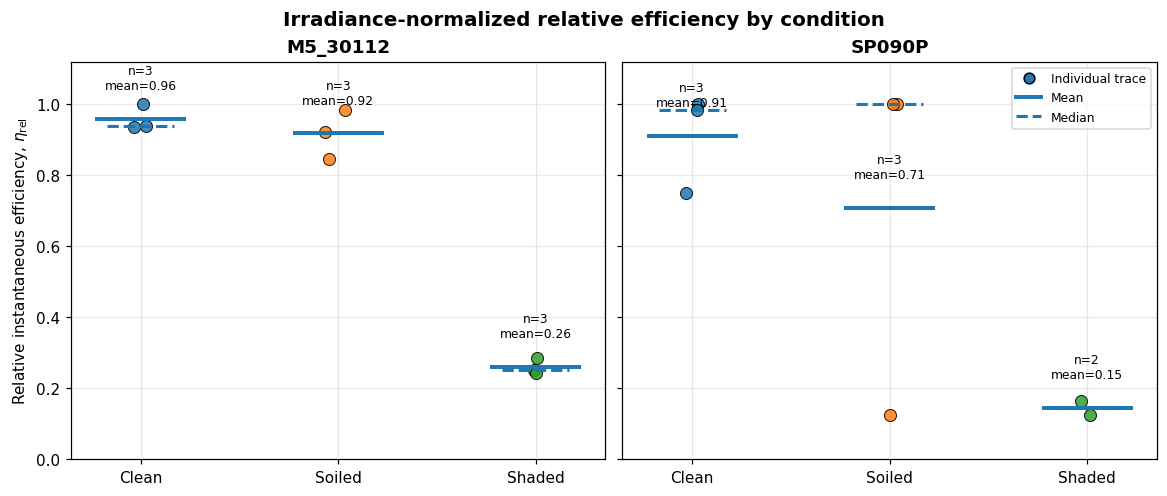

Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs/figures/Fig1_eta_rel_by_condition.png
Saved: /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs/figures/Fig1_eta_rel_by_condition.pdf


In [36]:
# ============================================================
# Fig. 1 — Relative efficiency by condition
# Dot plots + mean / median bars
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Make sure output folder exists ---
fig_dir = Path(OUT_DIR) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# --- Plot settings ---
condition_order = ["Clean", "Soiled", "Shaded"]
condition_labels = {
    "Clean": "Clean",
    "Soiled": "Soiled",
    "Shaded": "Shaded",
}

panel_order = ["M5_30112", "SP090P"]

# Use only rows with finite clipped relative efficiency
plot_df = df.copy()
plot_df = plot_df[np.isfinite(plot_df["eta_rel"])].copy()

if plot_df.empty:
    raise ValueError("No finite eta_rel values found. Check G_Wm2, Phi, Phi_ref, and eta_rel calculation.")

# --- Create figure ---
fig, axes = plt.subplots(
    1, 2,
    figsize=(10.5, 4.4),
    sharey=True,
    constrained_layout=True
)

rng = np.random.default_rng(42)

for ax, panel in zip(axes, panel_order):
    sub = plot_df[plot_df["panel"] == panel].copy()

    if sub.empty:
        ax.text(
            0.5, 0.5,
            f"No data for {panel}",
            ha="center", va="center",
            transform=ax.transAxes
        )
        ax.set_axis_off()
        continue

    x_positions = np.arange(len(condition_order))

    for i, cond in enumerate(condition_order):
        vals = sub.loc[sub["condition"] == cond, "eta_rel"].dropna().values

        if len(vals) == 0:
            continue

        # Small deterministic jitter so individual points do not overlap
        jitter = rng.normal(loc=0.0, scale=0.035, size=len(vals))
        x = np.full(len(vals), i, dtype=float) + jitter

        # Individual traces
        ax.scatter(
            x, vals,
            s=62,
            alpha=0.85,
            edgecolor="black",
            linewidth=0.7,
            zorder=3,
            label=None
        )

        # Mean bar
        mean_val = np.mean(vals)
        ax.hlines(
            mean_val,
            i - 0.23, i + 0.23,
            linewidth=2.6,
            linestyle="-",
            zorder=4
        )

        # Median bar
        median_val = np.median(vals)
        ax.hlines(
            median_val,
            i - 0.17, i + 0.17,
            linewidth=2.0,
            linestyle="--",
            zorder=4
        )

        # Annotate n and mean
        ax.text(
            i,
            min(1.08, mean_val + 0.075),
            f"n={len(vals)}\nmean={mean_val:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(panel, fontsize=12, fontweight="bold")
    ax.set_xticks(x_positions)
    ax.set_xticklabels([condition_labels[c] for c in condition_order])
    ax.set_ylim(0, 1.12)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

axes[0].set_ylabel(r"Relative instantaneous efficiency, $\eta_{\mathrm{rel}}$")

# Legend for mean / median bars
legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="None",
               markeredgecolor="black", markersize=7, label="Individual trace"),
    plt.Line2D([0], [0], linestyle="-", linewidth=2.6, label="Mean"),
    plt.Line2D([0], [0], linestyle="--", linewidth=2.0, label="Median"),
]

axes[1].legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fontsize=8
)

fig.suptitle(
    "Irradiance-normalized relative efficiency by condition",
    fontsize=13,
    fontweight="bold"
)

# --- Save figure ---
fig_path_png = fig_dir / "Fig1_eta_rel_by_condition.png"
fig_path_pdf = fig_dir / "Fig1_eta_rel_by_condition.pdf"

fig.savefig(fig_path_png, dpi=400, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print(f"Saved: {fig_path_png}")
print(f"Saved: {fig_path_pdf}")

saved Fig2_RI_vs_eta


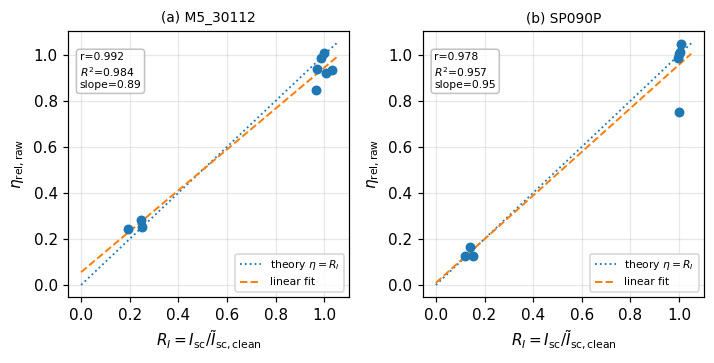

In [37]:
# Fig. 2 - R_I vs eta_rel_raw with linear fit (dashed) and theory y=x (dotted)
fig, axes = plt.subplots(1, len(PANEL_LIST), figsize=(6.6, 3.4), squeeze=False)
for ax, panel, tag in zip(axes[0], PANEL_LIST, "abcd"):
    sub = df[(df["panel"] == panel)][["R_I", "eta_rel_raw"]].dropna()
    ax.scatter(sub["R_I"], sub["eta_rel_raw"], s=30, zorder=3)
    s = stats_by_panel[panel]
    xs = np.linspace(0, max(1.05, sub["R_I"].max() if len(sub) else 1.05), 50)
    ax.plot(xs, xs, ls=":", lw=1.2, label="theory $\\eta=R_I$")
    if np.isfinite(s["slope"]):
        ax.plot(xs, s["slope"] * xs + s["intercept"], ls="--", lw=1.3, label="linear fit")
        ax.text(0.04, 0.92,
                f"r={s['pearson_r']:.3f}\n$R^2$={s['R2']:.3f}\nslope={s['slope']:.2f}",
                transform=ax.transAxes, va="top", fontsize=7,
                bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.8))
    ax.set_xlabel(r"$R_I = I_{\mathrm{sc}}/\tilde I_{\mathrm{sc,clean}}$")
    ax.set_ylabel(r"$\eta_{\mathrm{rel,raw}}$")
    ax.set_title(f"({tag}) {panel}", fontsize=9)
    ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
save_fig(fig, "Fig2_RI_vs_eta")
plt.show()


saved Fig3_representative_IV_PV


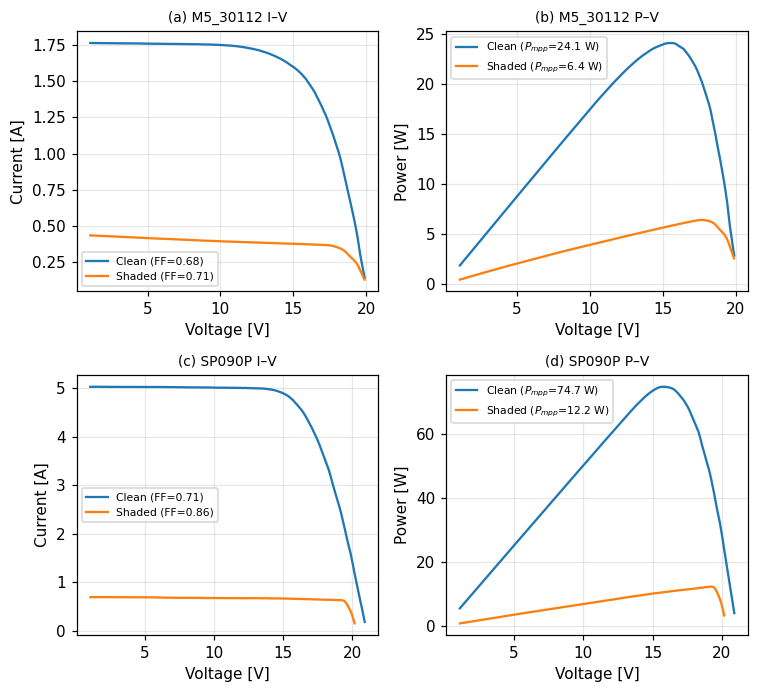

In [38]:
# Fig. 3 - representative I-V (a,c) and P-V (b,d), clean vs shaded, both panels
def pick(sub, cond, how="max"):
    pool = sub[(sub["condition"] == cond) & sub["eta_rel_raw"].notna()]
    if not len(pool):
        return None
    if how == "max":
        return pool.loc[pool["eta_rel_raw"].idxmax()]
    med = pool["eta_rel_raw"].median()
    return pool.loc[(pool["eta_rel_raw"] - med).abs().idxmin()]

fig, axes = plt.subplots(len(PANEL_LIST), 2, figsize=(7.0, 3.2 * len(PANEL_LIST)), squeeze=False)
tags = iter("abcdefgh")

for r, panel in enumerate(PANEL_LIST):
    sub = df[df["panel"] == panel]
    rc, rs = pick(sub, "Clean", "max"), pick(sub, "Shaded", "median")
    ax_iv, ax_pv = axes[r][0], axes[r][1]

    if rc is None or rs is None:
        ax_iv.text(0.5, 0.5, f"Missing clean or shaded\nfinite $\\eta_{{rel,raw}}$ trace\nfor {panel}",
                   ha="center", va="center", transform=ax_iv.transAxes)
        ax_pv.text(0.5, 0.5, f"Missing clean or shaded\nfinite $\\eta_{{rel,raw}}$ trace\nfor {panel}",
                   ha="center", va="center", transform=ax_pv.transAxes)
    else:
        for row, lab in ((rc, "Clean"), (rs, "Shaded")):
            v, i, _, _, _ = load_iv(row["file"])
            p = v * i
            ax_iv.plot(v, i, label=f"{lab} (FF={row['FF']:.2f})")
            ax_pv.plot(v, p, label=f"{lab} ($P_{{mpp}}$={row['Pmpp_W']:.1f} W)")

    ax_iv.set_xlabel("Voltage [V]"); ax_iv.set_ylabel("Current [A]")
    ax_pv.set_xlabel("Voltage [V]"); ax_pv.set_ylabel("Power [W]")
    ax_iv.set_title(f"({next(tags)}) {panel} I–V", fontsize=9)
    ax_pv.set_title(f"({next(tags)}) {panel} P–V", fontsize=9)
    ax_iv.legend(fontsize=7); ax_pv.legend(fontsize=7)

fig.tight_layout()
save_fig(fig, "Fig3_representative_IV_PV")
plt.show()

saved Fig4_threshold_sensitivity


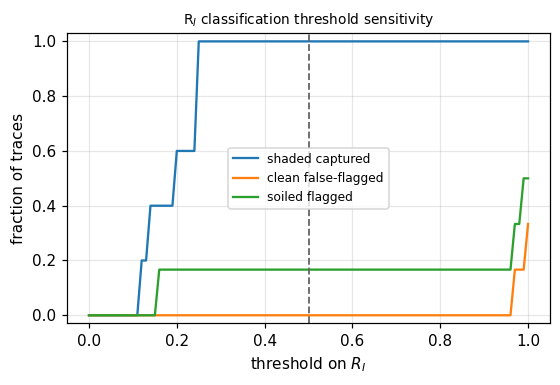

In [39]:
# Fig. 4 - threshold sensitivity of R_I classification
thr = np.linspace(0.0, 1.0, 101)
shaded = df.loc[df["condition"] == "Shaded", "R_I"].dropna().values
clean  = df.loc[df["condition"] == "Clean",  "R_I"].dropna().values
soiled = df.loc[df["condition"] == "Soiled", "R_I"].dropna().values

def frac_below(arr, t):
    return np.nan if len(arr) == 0 else float(np.mean(arr < t))

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.plot(thr, [frac_below(shaded, t) for t in thr], label="shaded captured")
ax.plot(thr, [frac_below(clean,  t) for t in thr], label="clean false-flagged")
ax.plot(thr, [frac_below(soiled, t) for t in thr], label="soiled flagged")
ax.axvline(ISC_COLLAPSE_THRESHOLD, ls="--", lw=1.2, color="0.4")
ax.set_xlabel(r"threshold on $R_I$"); ax.set_ylabel("fraction of traces")
ax.set_ylim(-0.03, 1.03); ax.legend(fontsize=8)
ax.set_title("R$_I$ classification threshold sensitivity", fontsize=9)
fig.tight_layout()
save_fig(fig, "Fig4_threshold_sensitivity")
plt.show()


saved Fig5_temperature_by_condition


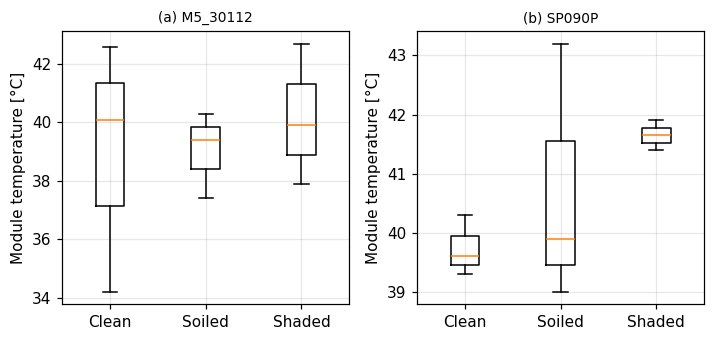

In [40]:
# Fig. 5 - module temperature distributions by condition
fig, axes = plt.subplots(1, len(PANEL_LIST), figsize=(6.6, 3.2), squeeze=False)
for ax, panel, tag in zip(axes[0], PANEL_LIST, "abcd"):
    sub = df[(df["panel"] == panel) & df["T_C"].notna()]
    cs = conds_present(sub)
    groups = [sub.loc[sub["condition"] == c, "T_C"].values for c in cs]
    if any(len(g) for g in groups):
        ax.boxplot(groups, tick_labels=cs, showfliers=True)
    ax.set_ylabel("Module temperature [°C]")
    ax.set_title(f"({tag}) {panel}", fontsize=9)
fig.tight_layout()
save_fig(fig, "Fig5_temperature_by_condition")
plt.show()


saved Fig6_SP090P_anomaly


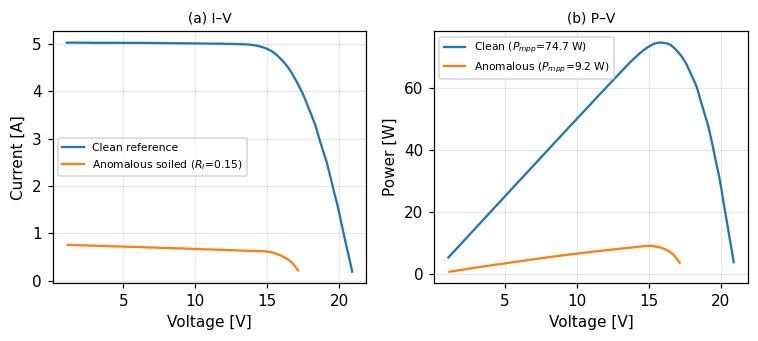

Fig. 6 trace selected:
panel                   SP090P
trace          Panel1_Dirt.mat
condition               Soiled
G_Wm2                    942.0
T_C                       43.2
R_I                   0.151231
eta_rel_raw           0.124735
Pmpp_W                    9.22
FF                    0.687342
Name: 10, dtype: object


In [41]:
# Fig. 6 - SP090P clean reference vs anomalous soiled/current-collapse trace
# The figure is generated from the soiled trace with the lowest eta_rel_raw.
# If Panel1_Dirt exists, it is preferred because this is the anomalous trace discussed in the manuscript.
TARGET = "SP090P"

panel_matches = [p for p in df["panel"].unique() if str(p).lower() == TARGET.lower()]
if panel_matches:
    target_panel = panel_matches[0]
    sp = df[df["panel"] == target_panel]
    clean_row = pick(sp, "Clean", "max")
    soiled_pool = sp[(sp["condition"] == "Soiled") & sp["eta_rel_raw"].notna()].copy()

    if clean_row is not None and len(soiled_pool):
        m = soiled_pool["trace"].astype(str).str.contains("Panel1_Dirt", case=False, regex=False)
        anom_row = soiled_pool[m].iloc[0] if m.any() else soiled_pool.loc[soiled_pool["eta_rel_raw"].idxmin()]

        vc, ic, _, _, _ = load_iv(clean_row["file"])
        va, ia, _, _, _ = load_iv(anom_row["file"])
        pc, pa = vc * ic, va * ia

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 3.2))

        ax1.plot(vc, ic, label="Clean reference")
        ax1.plot(va, ia, label=f"Anomalous soiled ($R_I$={anom_row['R_I']:.2f})")
        ax1.set_xlabel("Voltage [V]"); ax1.set_ylabel("Current [A]")
        ax1.set_title("(a) I–V", fontsize=9); ax1.legend(fontsize=7)

        ax2.plot(vc, pc, label=f"Clean ($P_{{mpp}}$={clean_row['Pmpp_W']:.1f} W)")
        ax2.plot(va, pa, label=f"Anomalous ($P_{{mpp}}$={anom_row['Pmpp_W']:.1f} W)")
        ax2.set_xlabel("Voltage [V]"); ax2.set_ylabel("Power [W]")
        ax2.set_title("(b) P–V", fontsize=9); ax2.legend(fontsize=7)

        fig.tight_layout()
        save_fig(fig, "Fig6_SP090P_anomaly")
        plt.show()

        print("Fig. 6 trace selected:")
        print(anom_row[["panel", "trace", "condition", "G_Wm2", "T_C", "R_I", "eta_rel_raw", "Pmpp_W", "FF"]])
    else:
        print("[WARN] SP090P clean or finite soiled pool missing; Fig.6 skipped.")
        print("SP090P condition counts:")
        print(sp.groupby("condition").size())
        print("SP090P finite eta_rel_raw by condition:")
        print(sp.groupby("condition")["eta_rel_raw"].apply(lambda s: s.notna().sum()))
else:
    print("[WARN] SP090P not present; Fig.6 skipped.")
    print("Available panels:", sorted(df["panel"].unique()))

## 6. Output manifest

In [42]:
print("All outputs in", OUT_DIR)
for root, _, files in os.walk(OUT_DIR):
    for f in sorted(files):
        print(" ", os.path.relpath(os.path.join(root, f), OUT_DIR))


All outputs in /content/drive/MyDrive/Makaleler/Makale-Instantaneous Relative Efficiency/study_outputs
  condition_summary.csv
  iv_summary.csv
  iv_summary.parquet
  table2_correlation.csv
  table2_correlation.json
  table2_correlation.txt
  figures/Fig1_eta_rel_by_condition.pdf
  figures/Fig1_eta_rel_by_condition.png
  figures/Fig2_RI_vs_eta.pdf
  figures/Fig2_RI_vs_eta.png
  figures/Fig3_representative_IV_PV.pdf
  figures/Fig3_representative_IV_PV.png
  figures/Fig4_threshold_sensitivity.pdf
  figures/Fig4_threshold_sensitivity.png
  figures/Fig5_temperature_by_condition.pdf
  figures/Fig5_temperature_by_condition.png
  figures/Fig6_SP090P_anomaly.pdf
  figures/Fig6_SP090P_anomaly.png
